In [1]:
import numpy as np
import pandas as pd
import pickle
from skimage.measure import  regionprops, regionprops_table
from skimage.io import imread, imsave, imshow
from skimage.morphology import medial_axis
from collections import defaultdict, deque

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [2]:
tracksgeo_path = 'tracks_geo_region.pkl'
tracksgeo_dict = pd.read_pickle(tracksgeo_path)

In [3]:
for df in tracksgeo_dict['soft_gel_ARPC2KO']:
    if df['experiment'].iloc[0] == '20240906_Jr20ARPC2KO' and df['movie'].iloc[0] == 45 and df['track_id'].iloc[0] == 12:
        track_df = df

In [4]:
track_df['solidity'].iloc[25]

0.33614274867122246

In [5]:
mask_path = '/proj/telston_lab/projects/data/DataForTFM/TFM_Data_02242025/2024_09_06_Jr2010xOvernight/ARPC2KO/movie45_track12/masks/t26.tif'
mask = imread(mask_path)

/nas/longleaf/home/emae/anaconda3/envs/shape_tfm_motion/lib/python3.10/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


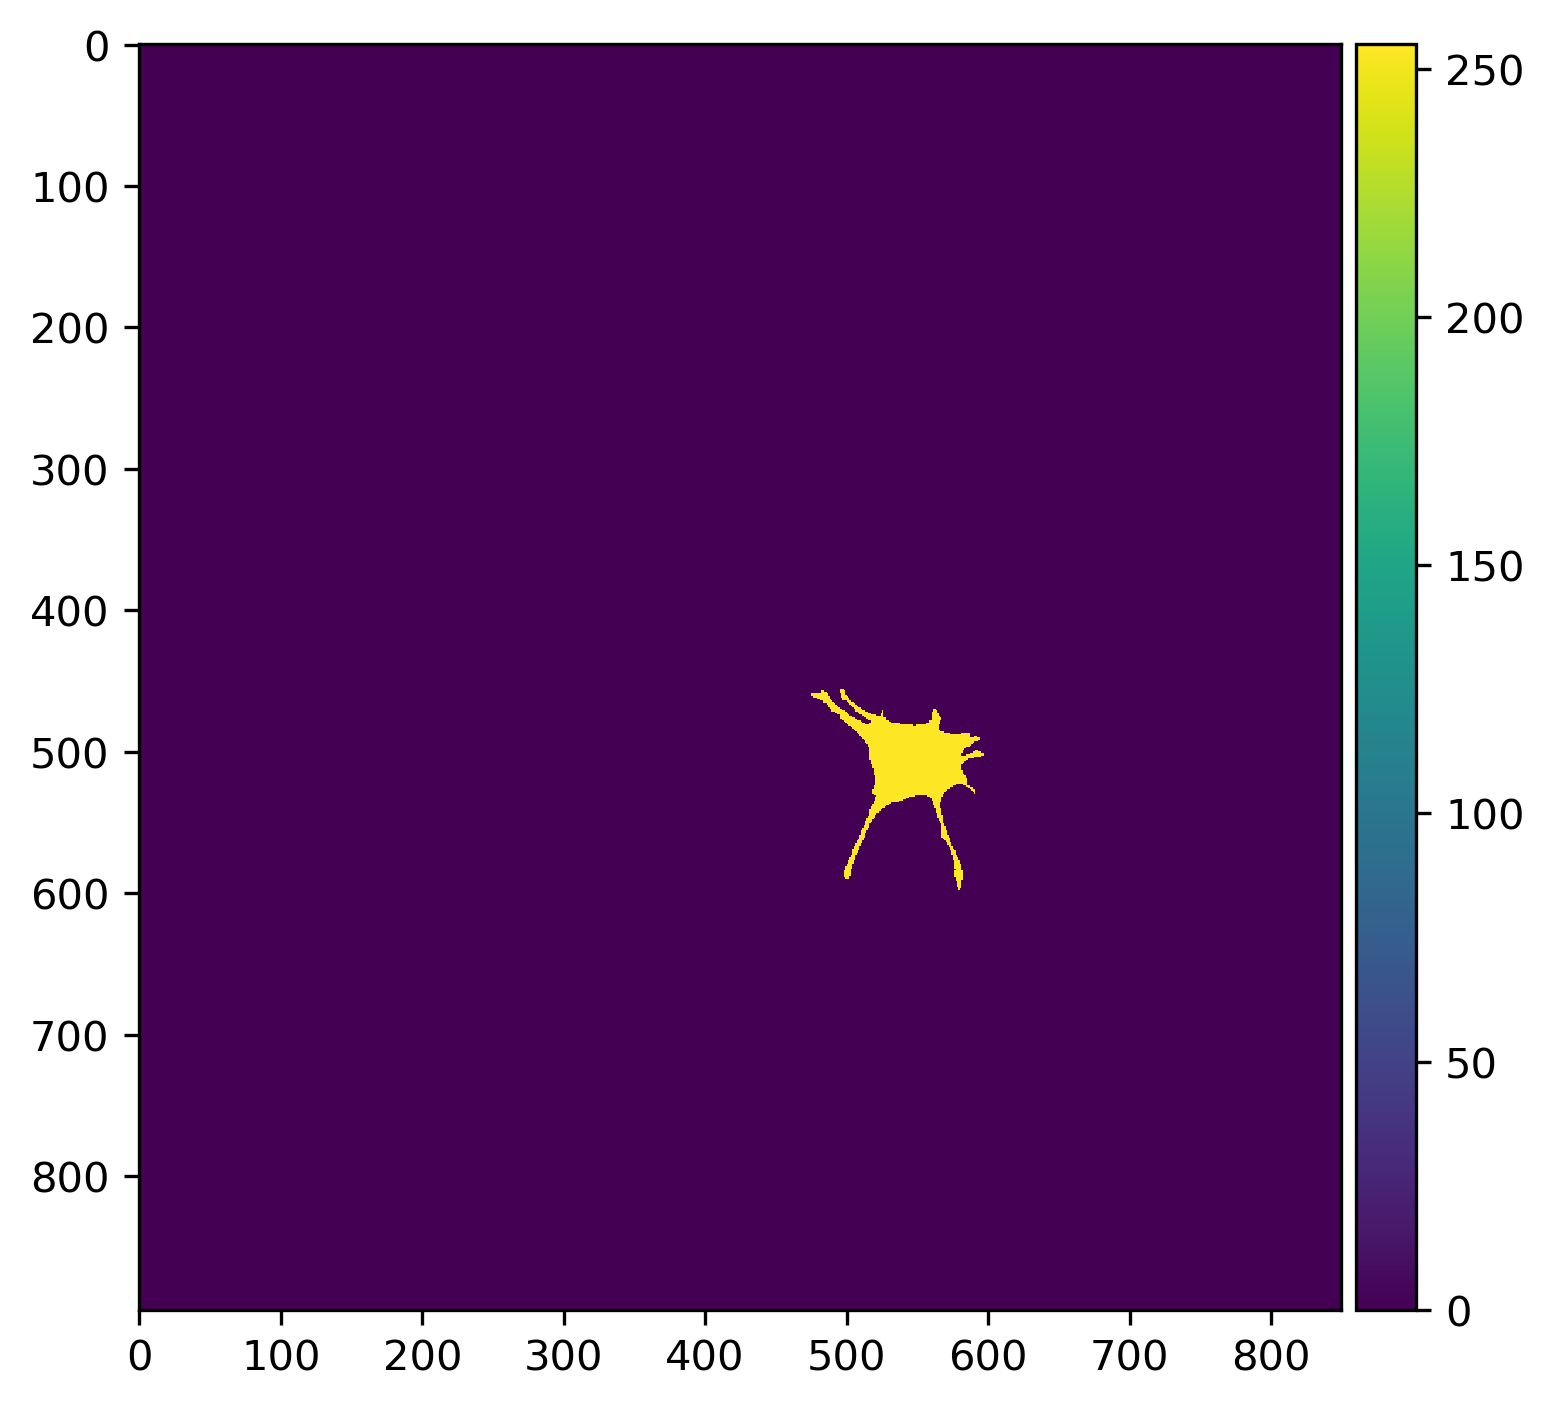

In [26]:
imshow(mask)

In [29]:
regionprops_table(mask,properties=['solidity'])

{'solidity': array([0.33614275])}

In [30]:
from skimage.morphology import remove_small_objects, binary_closing, disk

#mask = mask.astype(bool)

mask = remove_small_objects(mask, 100)
mask = binary_closing(mask, disk(2))
from skimage.measure import label

labeled = label(mask)

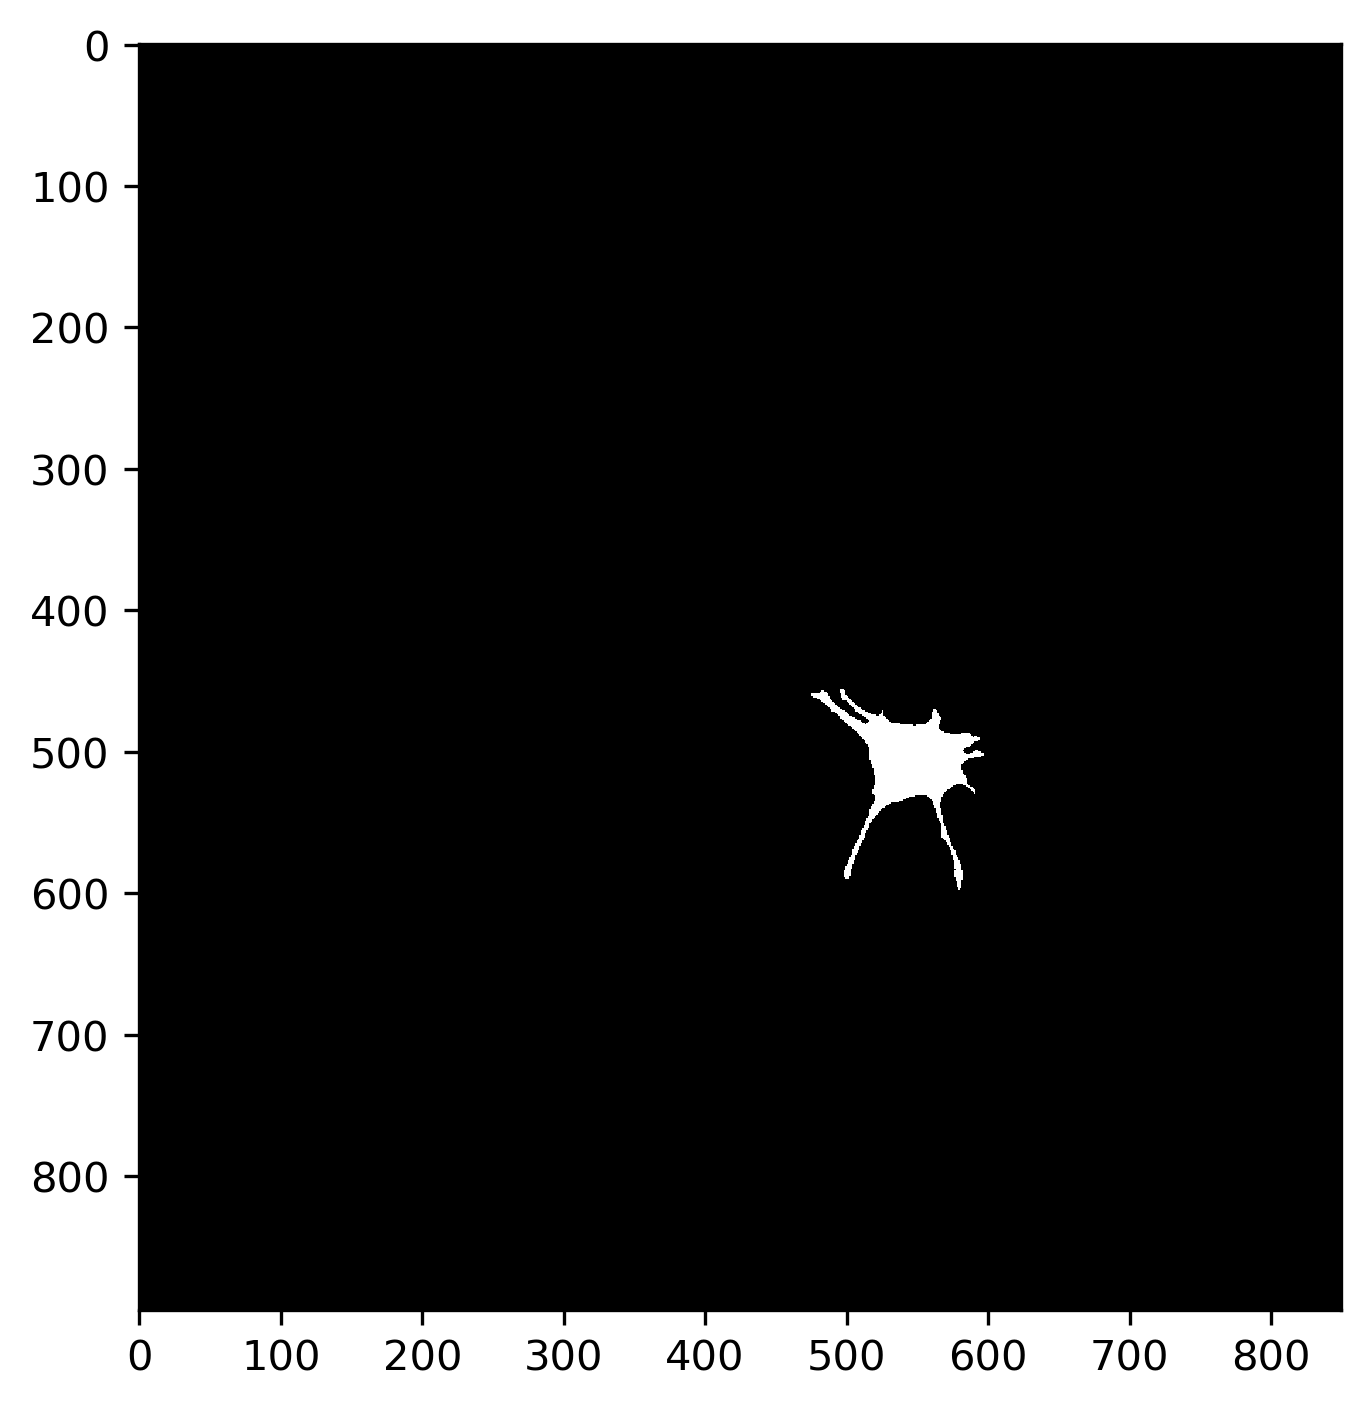

In [31]:
imshow(mask)

In [32]:
regionprops_table(labeled,properties=['solidity'])

{'solidity': array([0.33895216])}

# Protrusions with skeleton

In [6]:
import numpy as np
from skimage.morphology import remove_small_objects, binary_closing, disk, skeletonize
from scipy.ndimage import distance_transform_edt, convolve


def detect_protrusions_skeleton(
        mask,
        min_branch_length=12,
        min_width=3,
        clean_size=80,
        closing_radius=2
    ):

    mask = mask.astype(bool)

    mask = remove_small_objects(mask, clean_size)
    mask = binary_closing(mask, disk(closing_radius))

    skeleton = skeletonize(mask)

    dist = distance_transform_edt(mask)

    kernel = np.array([[1,1,1],
                       [1,10,1],
                       [1,1,1]])

    neighbors = convolve(skeleton.astype(int), kernel, mode="constant")

    endpoints = np.argwhere(neighbors == 11)
    junctions = np.argwhere(neighbors > 12)

    skel_coords = set(map(tuple, np.argwhere(skeleton)))

    visited = set()
    results = []

    def neighbors8(p):
        r,c = p
        for dr in [-1,0,1]:
            for dc in [-1,0,1]:
                if dr==0 and dc==0:
                    continue
                q = (r+dr, c+dc)
                if q in skel_coords:
                    yield q

    protrusion_id = 0

    for ep in map(tuple,endpoints):

        if ep in visited:
            continue

        branch = [ep]
        current = ep
        prev = None

        while True:

            nbrs = [n for n in neighbors8(current) if n != prev]

            if len(nbrs) == 0:
                break

            nxt = nbrs[0]

            branch.append(nxt)

            prev = current
            current = nxt

            if current in map(tuple,junctions):
                break

        for p in branch:
            visited.add(p)

        if len(branch) < min_branch_length:
            continue

        coords = np.array(branch)

        length = np.sum(
            np.sqrt(np.sum(np.diff(coords,axis=0)**2,axis=1))
        )

        widths = 2*dist[coords[:,0],coords[:,1]]

        mean_width = widths.mean()
        tip_width = widths[0]
        base_width = widths[-1]

        idx_75 = int(0.25 * len(coords))
        width_75 = widths[idx_75]
        width75_y = coords[idx_75, 0]
        width75_x = coords[idx_75, 1]

        if mean_width < min_width:
            continue

        results.append({
            "protrusion_id": protrusion_id,
            "tip_y": coords[0,0],
            "tip_x": coords[0,1],
            "base_y": coords[-1,0],
            "base_x": coords[-1,1],
            "length": length,
            "mean_width": mean_width,
            "tip_width": tip_width,
            "base_width": base_width,
            "width_75": width_75,
            "width75_y": width75_y,
            "width75_x": width75_x
        })

        protrusion_id += 1

    return results, skeleton, endpoints, junctions

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_protrusions(mask, skeleton, results):

    df = pd.DataFrame(results)

    plt.figure(figsize=(6,6))
    plt.imshow(mask, cmap="gray")

    skel_y, skel_x = np.where(skeleton)
    plt.scatter(skel_x, skel_y, s=0.05, color="cyan")

    # tips
    plt.scatter(df["tip_x"], df["tip_y"],
                color="lime", s=2, label="tip")

    # bases
    plt.scatter(df["base_x"], df["base_y"],
                color="yellow", s=2, label="base")

    # width_75 point
    plt.scatter(df["width75_x"], df["width75_y"],
                color="red", s=2, label="width_75")

    plt.legend()
    plt.title("Detected Protrusions")
    plt.axis("off")
    plt.show()

In [13]:
mask_path = '/proj/telston_lab/projects/data/DataForTFM/TFM_Data_02242025/2024_09_06_Jr2010xOvernight/ARPC2KO/movie45_track12/masks/t60.tif'
mask = imread(mask_path)

/nas/longleaf/home/emae/anaconda3/envs/shape_tfm_motion/lib/python3.10/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


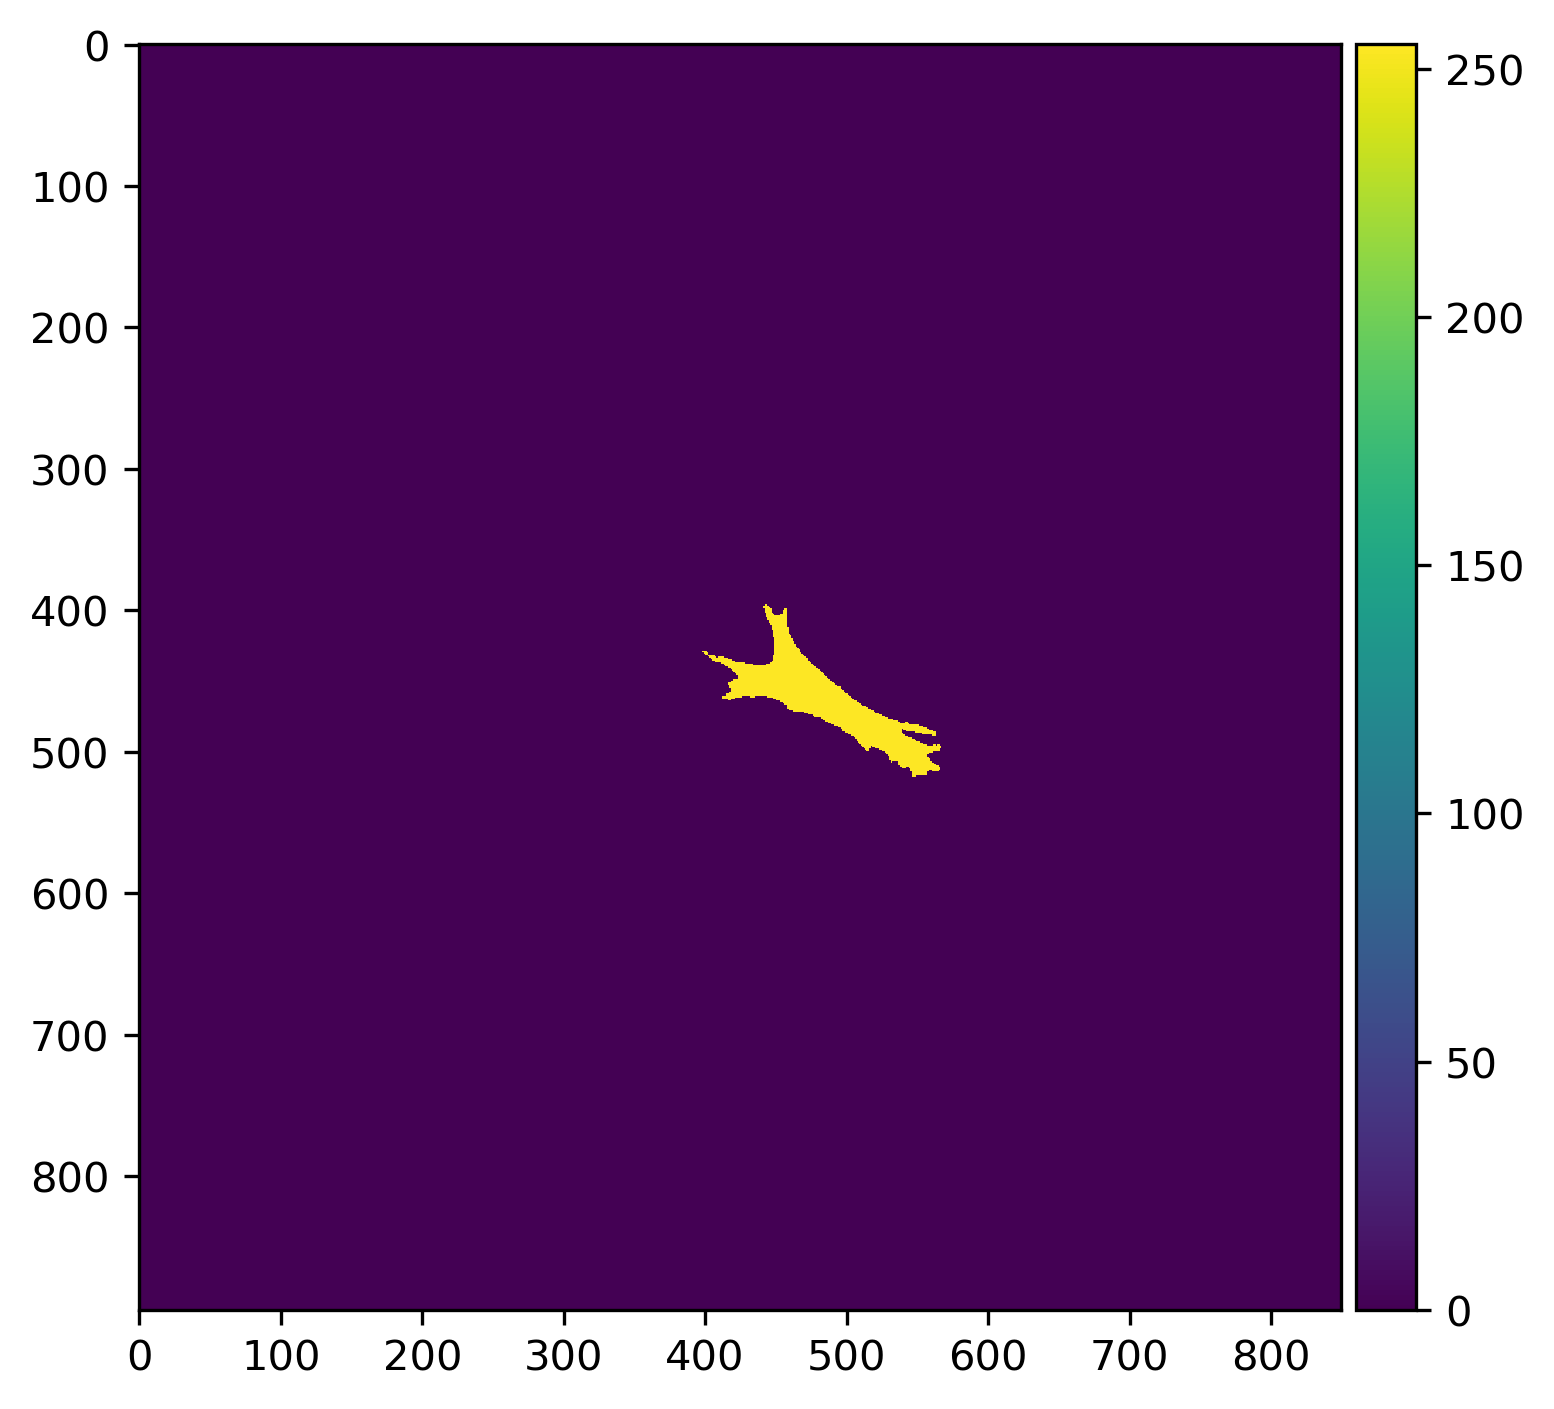

In [14]:
imshow(mask)

In [8]:
results, skeleton, endpoints, junctions=detect_protrusions_skeleton(mask)

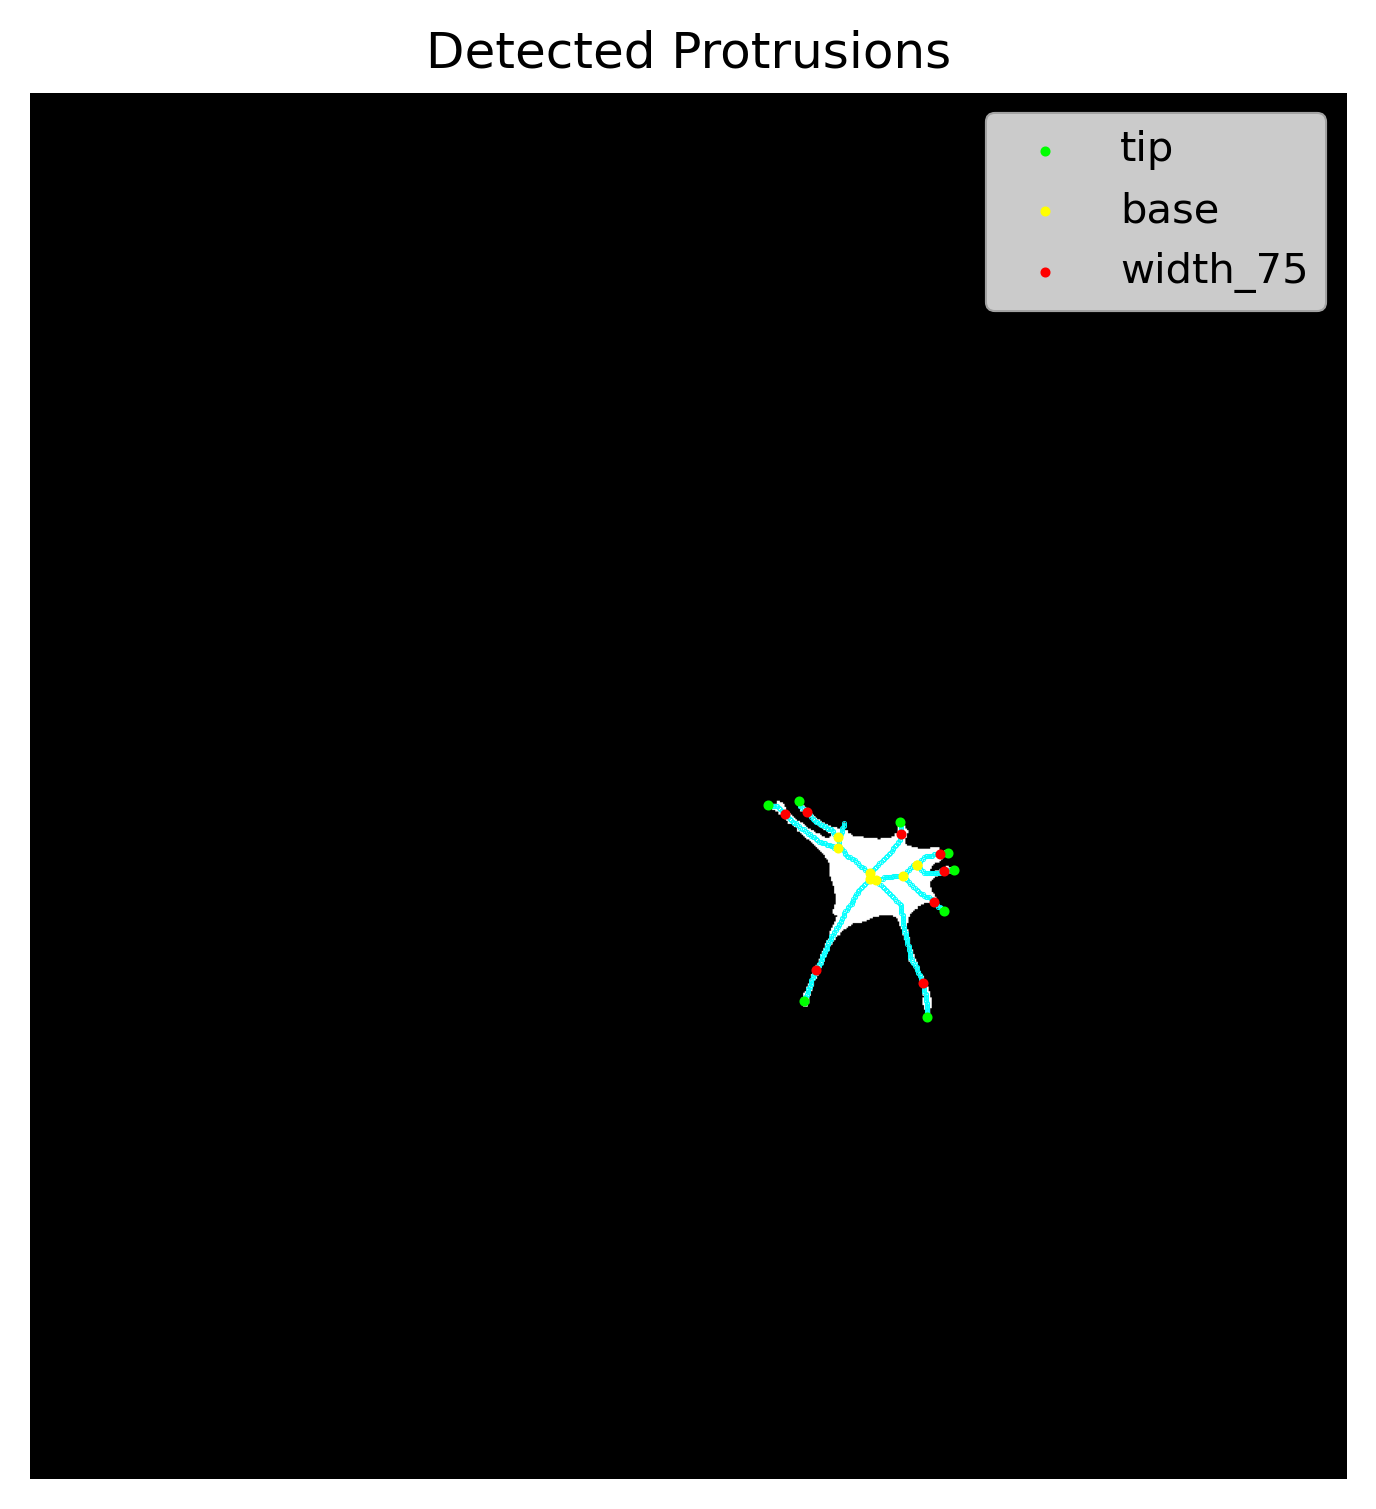

In [9]:
plot_protrusions(mask, skeleton, results)

In [17]:
results

[{'protrusion_id': 0,
  'tip_y': 398,
  'tip_x': 443,
  'base_y': 408,
  'base_x': 451,
  'length': 14.485281374238571,
  'mean_width': 6.016984580664784,
  'tip_width': 4.47213595499958,
  'base_width': 10.0,
  'width_75': 4.47213595499958,
  'width75_y': 401,
  'width75_x': 444},
 {'protrusion_id': 1,
  'tip_y': 432,
  'tip_x': 402,
  'base_y': 449,
  'base_x': 433,
  'length': 38.62741699796952,
  'mean_width': 7.769564725621372,
  'tip_width': 2.0,
  'base_width': 22.090722034374522,
  'width_75': 4.0,
  'width75_y': 435,
  'width75_x': 410},
 {'protrusion_id': 2,
  'tip_y': 486,
  'tip_x': 561,
  'base_y': 489,
  'base_x': 535,
  'length': 29.72792206135786,
  'mean_width': 7.2602799362722195,
  'tip_width': 2.0,
  'base_width': 18.110770276274835,
  'width_75': 5.656854249492381,
  'width75_y': 485,
  'width75_x': 555},
 {'protrusion_id': 3,
  'tip_y': 497,
  'tip_x': 564,
  'base_y': 503,
  'base_x': 549,
  'length': 17.485281374238575,
  'mean_width': 7.850203426096508,
  'tip_

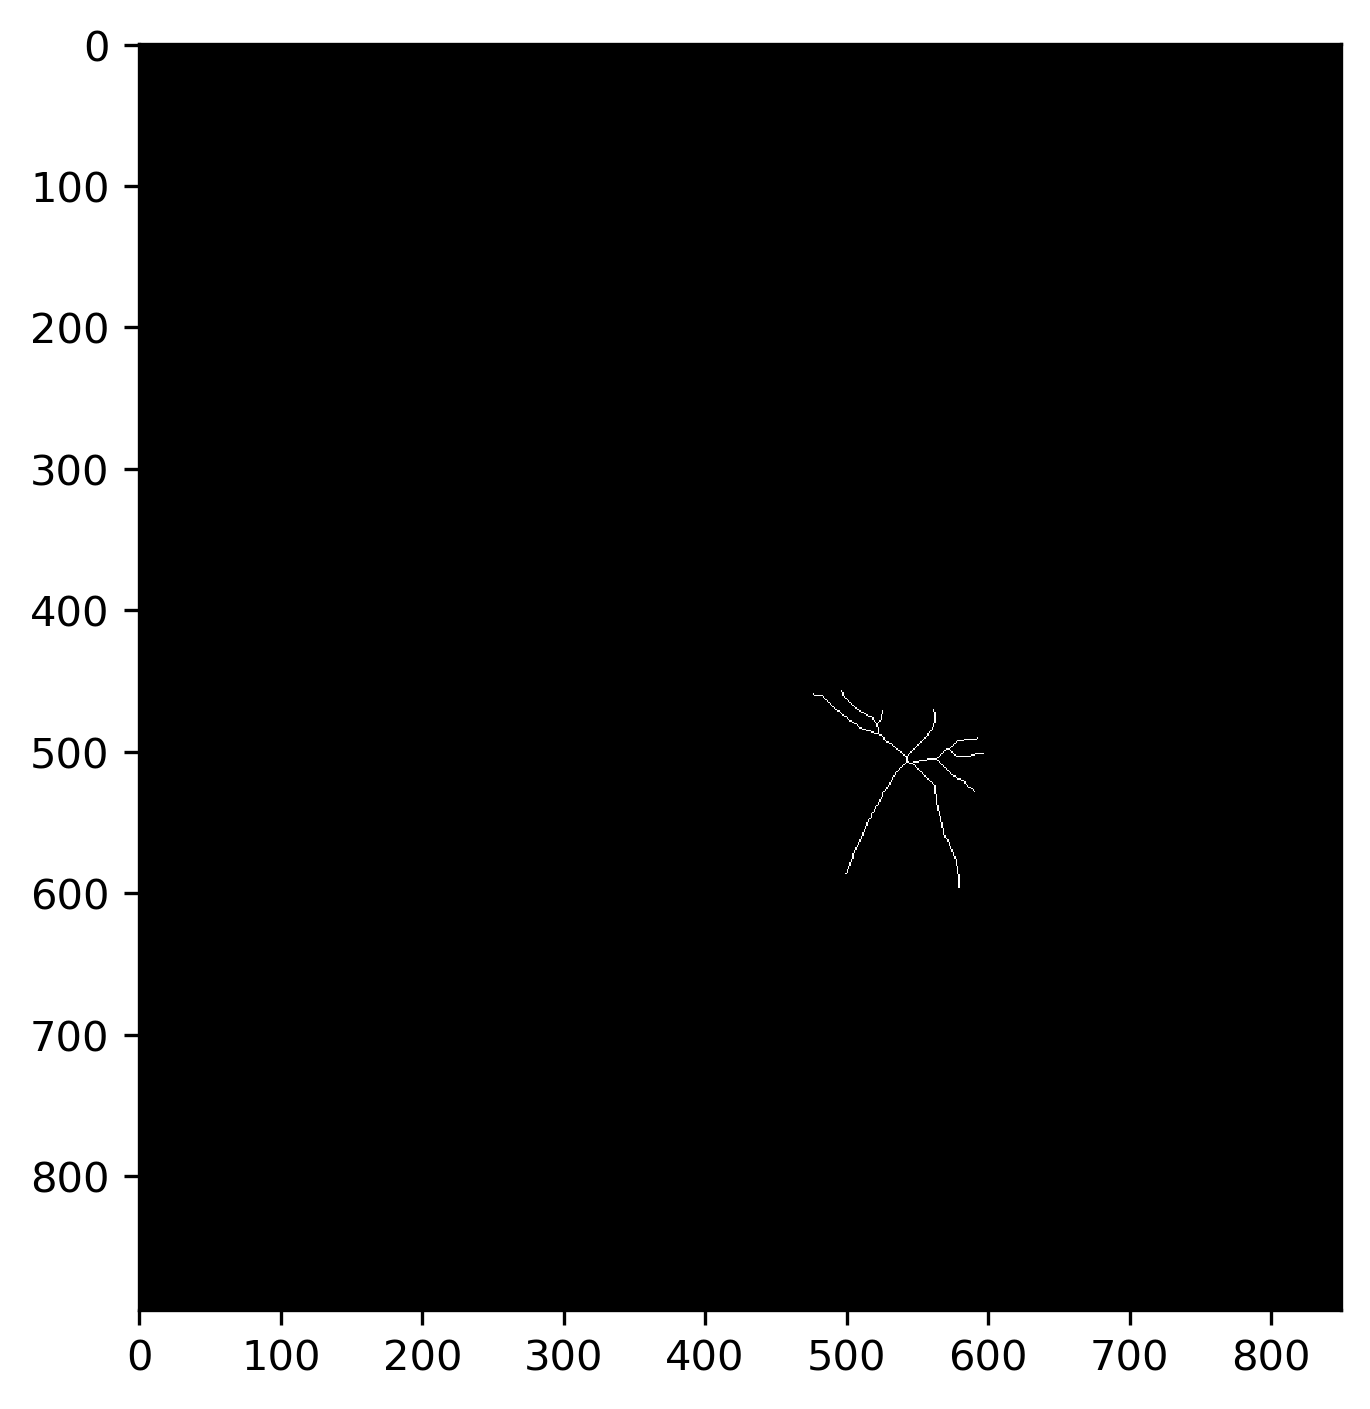

In [82]:
imshow(skeleton)

In [78]:
mask_path = '/proj/telston_lab/projects/data/DataForTFM/TFM_Data_02242025/2024_09_06_Jr2010xOvernight/ARPC2KO/movie45_track12/masks/t26.tif'
mask = imread(mask_path)

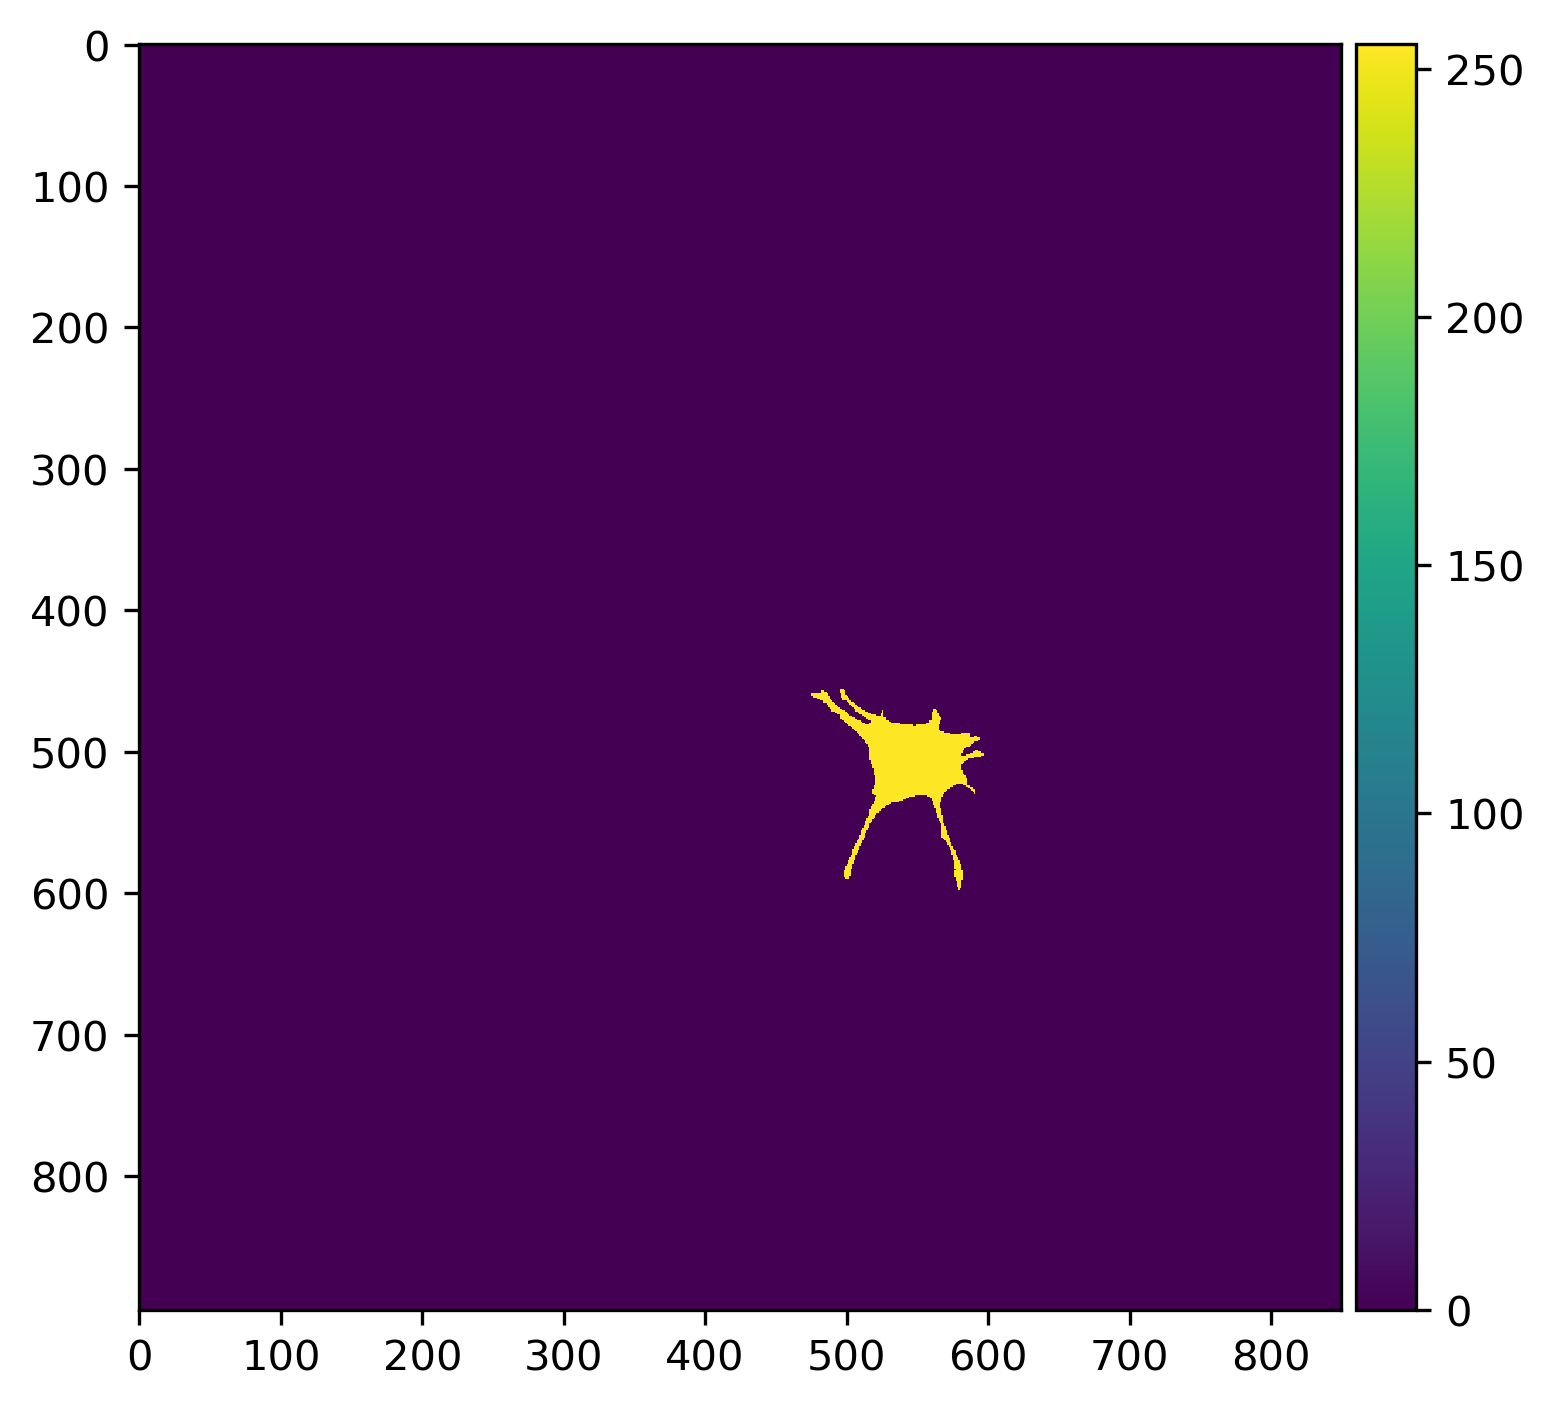

In [64]:
imshow(mask)

# Protrusions with curvature

In [44]:
import numpy as np
from skimage import measure
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks


def detect_protrusions_curvature(
        mask,
        smooth_sigma=3,
        prominence=0.02,
        min_tip_distance=20
    ):
    """
    Detect protrusions using boundary curvature.

    Parameters
    ----------
    mask : 2D binary array
    smooth_sigma : boundary smoothing
    prominence : peak prominence for tip detection
    min_tip_distance : minimum spacing between tips

    Returns
    -------
    results : list of protrusion measurements
    boundary : Nx2 array of boundary coordinates
    curvature : curvature along boundary
    tips : indices of tip points
    bases : list of (left,right) base indices
    """

    mask = mask.astype(bool)

    # ---- boundary extraction ----
    contour = measure.find_contours(mask, 0.5)[0]

    y = contour[:,0]
    x = contour[:,1]

    # ---- smooth boundary ----
    x_s = gaussian_filter1d(x, smooth_sigma, mode='wrap')
    y_s = gaussian_filter1d(y, smooth_sigma, mode='wrap')

    # ---- curvature calculation ----
    dx = np.gradient(x_s)
    dy = np.gradient(y_s)

    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    curvature = (dx*ddy - dy*ddx) / (dx*dx + dy*dy)**1.5

    # ---- detect protrusion tips ----
    tips, _ = find_peaks(curvature,
                         prominence=prominence,
                         distance=min_tip_distance)

    # ---- find bases ----
    bases = []
    results = []

    N = len(curvature)

    def walk(idx, direction):
        i = idx
        while True:
            i = (i + direction) % N
            if curvature[i] < 0:
                return i

    for tip in tips:

        left = walk(tip, -1)
        right = walk(tip, 1)

        bases.append((left, right))

        # ---- width ----
        width = np.sqrt((x_s[left]-x_s[right])**2 +
                        (y_s[left]-y_s[right])**2)

        # ---- base midpoint ----
        base_x = (x_s[left] + x_s[right]) / 2
        base_y = (y_s[left] + y_s[right]) / 2

        # ---- length ----
        length = np.sqrt((x_s[tip]-base_x)**2 +
                         (y_s[tip]-base_y)**2)

        results.append({
            "tip_index": tip,
            "length": length,
            "width": width,
            "aspect_ratio": length/width if width > 0 else np.nan
        })

    boundary = np.vstack([x_s, y_s]).T

    return results, boundary, curvature, tips, bases

In [70]:
import matplotlib.pyplot as plt


def visualize_protrusions(mask, boundary, tips, bases):

    plt.figure(figsize=(6,6))

    plt.imshow(mask, cmap="gray")

    # boundary
    plt.plot(boundary[:,0], boundary[:,1], 'b', linewidth=1)

    # tips
    for t in tips:
        plt.scatter(boundary[t,0], boundary[t,1],
                    color='red', s=20, label='tip')

    # bases
    for left, right in bases:
        plt.scatter(boundary[left,0], boundary[left,1],
                    color='cyan', s=10)

        plt.scatter(boundary[right,0], boundary[right,1],
                    color='cyan', s=10)

        plt.plot([boundary[left,0], boundary[right,0]],
                 [boundary[left,1], boundary[right,1]],
                 color='yellow')

    plt.title("Curvature-based protrusion detection")
    plt.axis('off')
    plt.show()

In [105]:
mask_path = '/proj/telston_lab/projects/data/DataForTFM/TFM_Data_02242025/2024_09_06_Jr2010xOvernight/ARPC2KO/movie45_track12/masks/t26.tif'
mask = imread(mask_path)

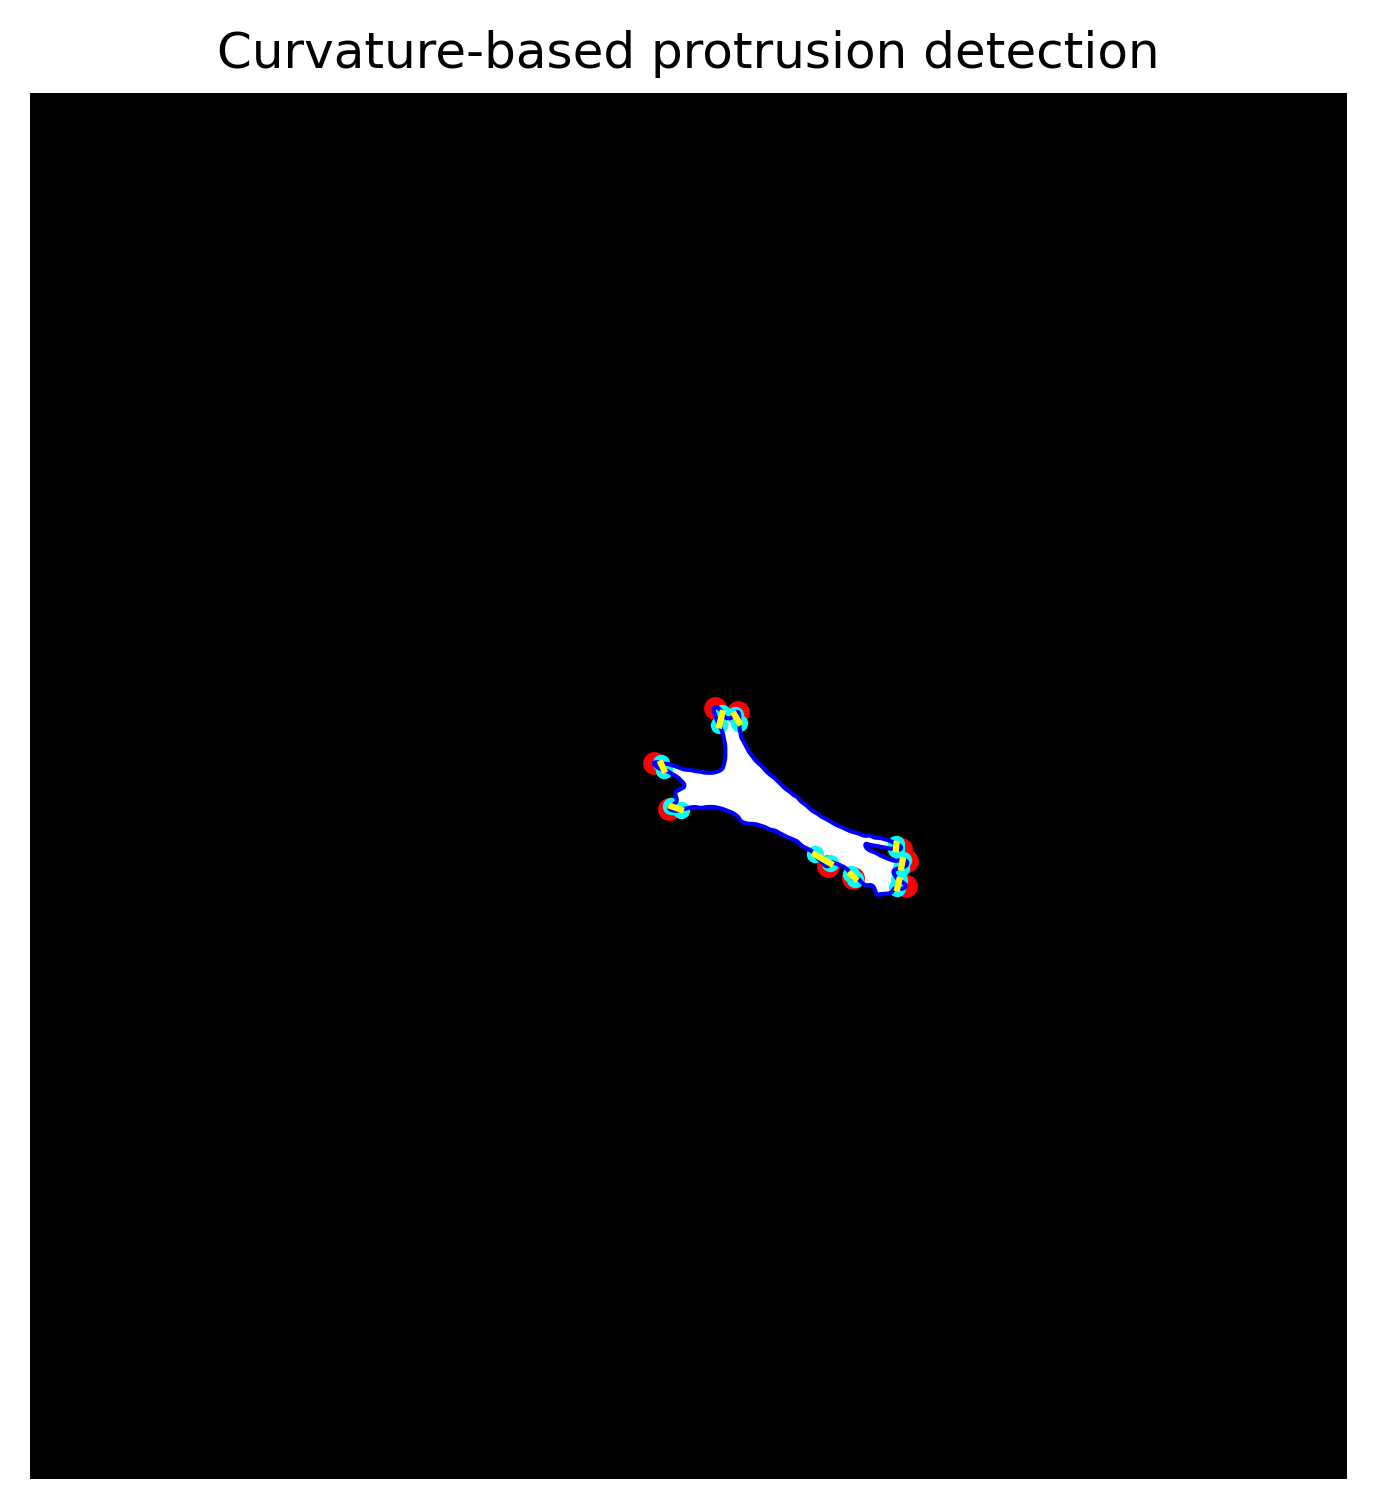

In [94]:
results, boundary, curvature, tips, bases = detect_protrusions_curvature(mask,smooth_sigma=2,
        prominence=0.5,
        min_tip_distance=20)

visualize_protrusions(mask, boundary, tips, bases)

In [88]:
len(results)

7

# Convex hull method

In [110]:
import numpy as np
from skimage.measure import find_contours
from scipy.spatial import ConvexHull
from scipy.spatial.distance import euclidean


def measure_protrusions_hull(mask, min_length=1, min_width=2):

    contours = find_contours(mask, 0.5)

    if len(contours) == 0:
        return []

    contour = max(contours, key=len)

    # convert to (x,y)
    pts = np.fliplr(contour)

    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]

    protrusions = []

    for i in range(len(hull_pts)):

        p1 = hull_pts[i]
        p2 = hull_pts[(i+1) % len(hull_pts)]

        # find contour points between hull vertices
        segment_mask = (
            (pts[:,0] >= min(p1[0], p2[0])) &
            (pts[:,0] <= max(p1[0], p2[0])) &
            (pts[:,1] >= min(p1[1], p2[1])) &
            (pts[:,1] <= max(p1[1], p2[1]))
        )

        segment = pts[segment_mask]

        if len(segment) == 0:
            continue

        # farthest point from hull edge = protrusion tip
        line_vec = p2 - p1
        line_len = np.linalg.norm(line_vec)

        if line_len == 0:
            continue

        line_unit = line_vec / line_len

        dists = []

        for p in segment:

            vec = p - p1
            proj = np.dot(vec, line_unit) * line_unit
            perp = vec - proj

            dists.append(np.linalg.norm(perp))

        idx = np.argmax(dists)
        tip = segment[idx]

        width = euclidean(p1, p2)
        length = np.max(dists)

        if width < min_width or length < min_length:
            continue

        protrusions.append({
            "tip": np.array([tip[1], tip[0]]),
            "base1": np.array([p1[1], p1[0]]),
            "base2": np.array([p2[1], p2[0]]),
            "length": length,
            "width": width
        })

    return protrusions

In [111]:
import matplotlib.pyplot as plt


def visualize_protrusions(mask, protrusions):

    plt.figure(figsize=(6,6))
    plt.imshow(mask, cmap="gray")

    for p in protrusions:

        tip = p["tip"]
        base1 = p["base1"]
        base2 = p["base2"]

        # tip
        plt.scatter(tip[1], tip[0], c="red", s=60)

        # base
        plt.plot(
            [base1[1], base2[1]],
            [base1[0], base2[0]],
            c="cyan",
            linewidth=2
        )

        # length
        base_mid = (base1 + base2) / 2

        plt.plot(
            [tip[1], base_mid[1]],
            [tip[0], base_mid[0]],
            c="yellow",
            linewidth=2
        )

    plt.title(f"Detected protrusions: {len(protrusions)}")
    plt.axis("off")
    plt.show()

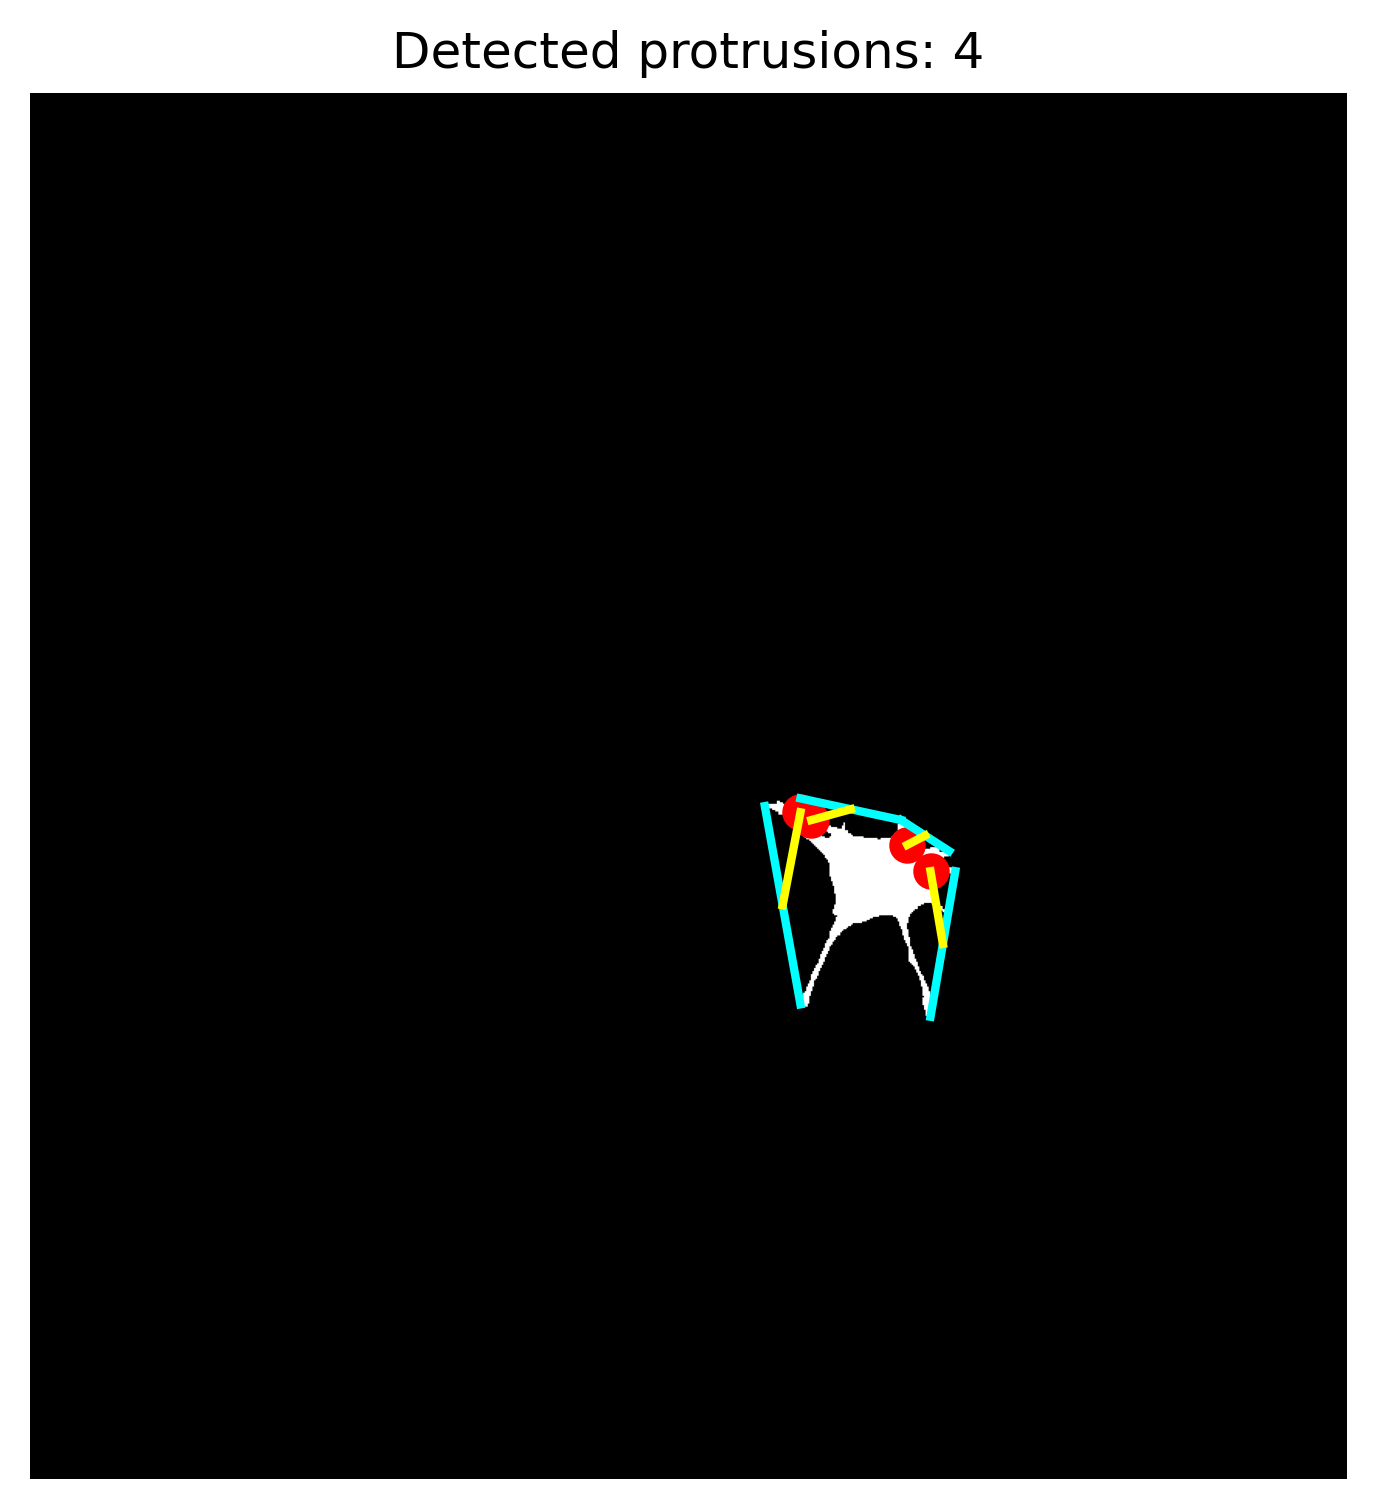

protrusion count: 4


In [112]:
protrusions = measure_protrusions_hull(
    mask,
    min_length=10,
    min_width=4
)

visualize_protrusions(mask, protrusions)

print("protrusion count:", len(protrusions))